In [1]:
pip install IPython

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Audio
from google.colab import output

In [3]:
def code_ran_noise(duration=0.5, frequency=600):
    output.eval_js(f"""
    const ctx = new (window.AudioContext || window.webkitAudioContext)();
    const oscillator = ctx.createOscillator();
    const gain = ctx.createGain();

    oscillator.type = "sine";
    oscillator.frequency.value = {frequency};

    gain.gain.value = 0.1;

    oscillator.connect(gain);
    gain.connect(ctx.destination);

    oscillator.start();
    oscillator.stop(ctx.currentTime + {duration});
    """)


code_ran_noise(5, 600)

In [4]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", as_frame= False) #mnist is images, hence why as_frame = as dataframe is set to false. Will return as a np aray

In [5]:
X,y = mnist.data, mnist.target

In [6]:
X # numpy array

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [7]:
X.shape #70,000 images, each image has 784 features

(70000, 784)

In [8]:
y#also an array

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [9]:
y.shape

(70000,)

In [10]:
# to plot the image
def plot_digit(image):
  image = image.reshape(28,28) # will reshape it into a 28 x 28 array (sqrt of 784 = 28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")


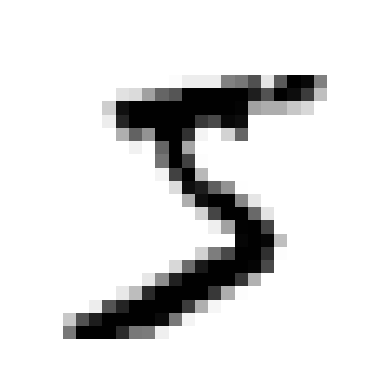

In [11]:
first_digit_image = X[0]

plot_digit(first_digit_image) # looks like a 5

In [12]:
y[0]  # is a 5

'5'

In [13]:
# the mnist dataset (returned by fetch_openml is split into a training (first 60k) and test set (last 10k) already)

X_train, y_train, X_test, y_test = X[:60000], y[:60000], X[60000:], y[60000:] # this one is shuffled and split but not all fetch_openml datasets are

**Binary Classifier**

In [14]:
y_train_5 = (y_train == "5") # True for all 5s, False for all other digits
y_test_5 = (y_test == "5")

In [15]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [16]:
sgd_clf.predict([first_digit_image])

array([ True])

In [17]:
second_digit_image = X[1]
sgd_clf.predict([second_digit_image]) #second_digit_image

array([False])

In [18]:
y[1]

'0'

In [19]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [20]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier() # strat is most frequent
dummy.fit(X_train, y_train_5)
cross_val_score(dummy, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [21]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


In [22]:
y_train_pred # returned prediction

array([ True, False, False, ...,  True, False, False])

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)

# Cm shows that the model is good at knowing what isnt a 5, but isnt good at knowing what is a 5

In [24]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_5, y_train_pred)*100)
print(recall_score(y_train_5, y_train_pred)*100)

83.70879772350011
65.11713705958311


In [25]:
from sklearn.metrics import f1_score

print(f1_score(y_train_5, y_train_pred))

0.7325171197343847


Precision/Recall Trade off

In [26]:
y_scores = sgd_clf.decision_function([first_digit_image])
y_scores

array([2164.22030239])

In [27]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
#the sgd classifier use a threshold of 0 (hence this code will return the same result as the predict function)

In [28]:
y_some_digit_pred

array([ True])

In [29]:
# if the threshold is raised...

threshold = 3000,
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred
# same value is now false. Raising the threshold decreased recall

array([False])

In [30]:
y_scores = cross_val_predict(sgd_clf, X_train,
                             y_train_5,
                             cv=3,
                             method="decision_function")

In [31]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

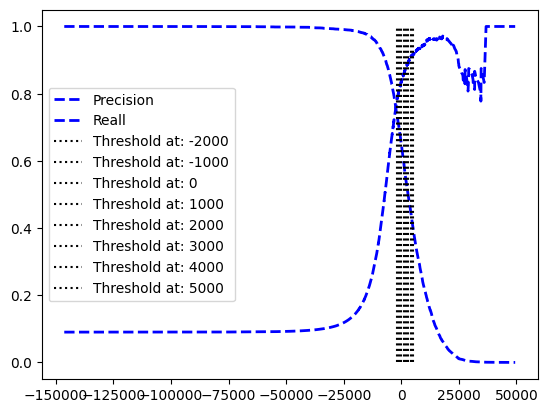

In [32]:
plt.plot(thresholds, precisions[:-1],"b--", label = "Precision", linewidth = 2)
plt.plot(thresholds, recalls[:-1],"b--", label = "Reall", linewidth = 2)


potential_thresholds = [-2000,-1000,0, 1000, 2000, 3000, 4000, 5000]
for i in potential_thresholds:
  plt.vlines(i, 0, 1.0, "k","dotted", label = f"Threshold at: {i}")

plt.legend()



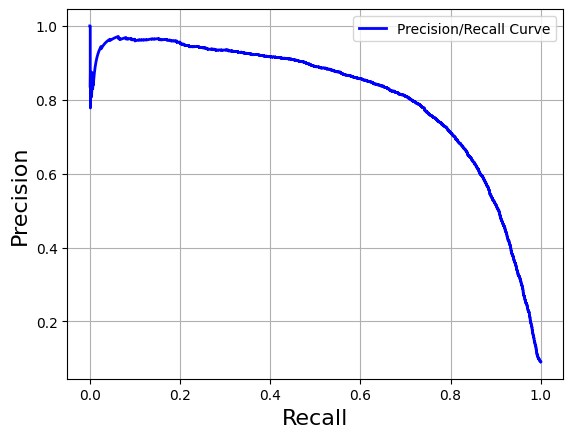

In [33]:
plt.plot(recalls, precisions, "b", linewidth = 2, label = "Precision/Recall Curve")
plt.xlabel("Recall", fontsize = 16)
plt.ylabel("Precision", fontsize = 16)
plt.legend()
plt.grid(True)

#precision falls off around 0.8 recall. Therefore best to select the precision/recall trade off just before drop off.
# The choice depends on the applications

In [34]:
idx_for_90_precision = (precisions >= 0.9).argmax()

threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

#searches for the lowest threshold that gives 90% precision. Returns the first index of the max value i.e. returns the first True value

np.float64(3370.0194991439557)

In [35]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [36]:
print(precision_score(y_train_5, y_train_pred_90))
print(recall_score(y_train_5, y_train_pred_90))

#90% precision is achieved but the recall is too low (at 48%)

0.9000345901072293
0.4799852425751706


The ROC Curve

In [37]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [38]:
idx_for_threshold_at_90 = (thresholds <=threshold_for_90_precision ).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

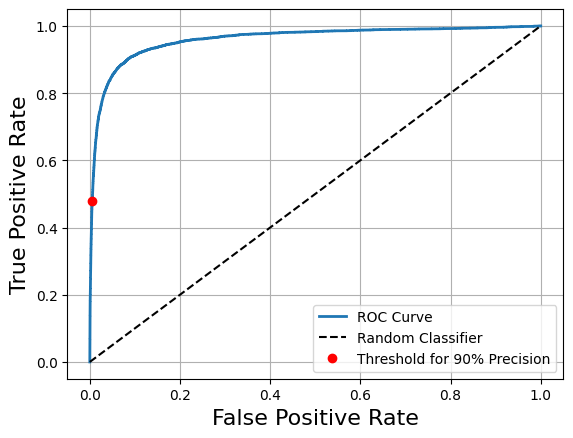

In [39]:
plt.plot(fpr, tpr, linewidth = 2, label = "ROC Curve")
plt.plot([0,1], [0,1], "k--", label = "Random Classifier")
plt.plot([fpr_90], [tpr_90], "ro", label = "Threshold for 90% Precision")
plt.xlabel("False Positive Rate", fontsize = 16)
plt.ylabel("True Positive Rate", fontsize = 16)
plt.legend()
plt.grid(True)

# a good classifier should be as far away as possible from the dotted line (topwards the top left).

#The graph shows that as the recall (TPR) increases the classifiers produces more false positives (FPR increases)

In [40]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_train_5, y_scores))


# A perfect classifier will have a ROC Area under curve (AUC) equal to 1.
# A random classifier will have AUC equal to 0.5

0.9604938554008616


In [41]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

y_probs = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

# randomforestclf, doesnt have decision functio but has a predict_proba methods that returns class probabilities for each instance

In [42]:
y_probs[:2]

# Returns an array with rows that equal the probabilities of False True.
# 0.11 = False, 0.89 = True for picture 1
# 0.99 = False, 0.01 = True for picture 2


# Note:

# These are estimated probabilites not actual probabilities

array([[0.11, 0.89],
       [0.99, 0.01]])

In [43]:
y_pos_scores = y_probs[:,1]

In [44]:
precisions_for, recalls_for, thresholds_for = precision_recall_curve(y_train_5, y_pos_scores)

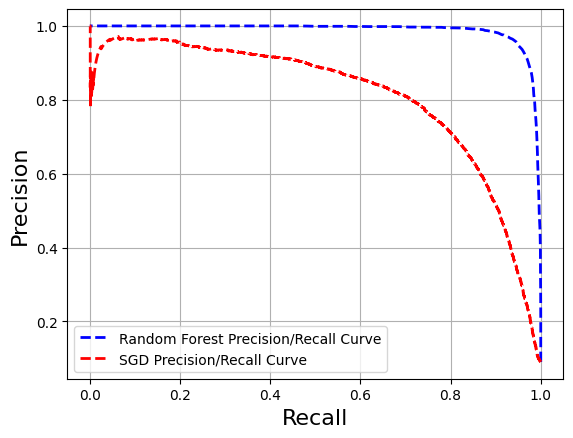

In [45]:
plt.plot(recalls_for, precisions_for, "b--", linewidth = 2, label = "Random Forest Precision/Recall Curve")
plt.plot(recalls, precisions, "r--", linewidth = 2, label = "SGD Precision/Recall Curve")
plt.xlabel("Recall", fontsize = 16)
plt.ylabel("Precision", fontsize = 16)
plt.legend()
plt.grid(True)

In [46]:
y_train_pred_for = y_pos_scores >= 0.5


print(f1_score(y_train_5, y_train_pred_for))
print(roc_auc_score(y_train_5, y_pos_scores))


0.9274509803921569
0.9983436731328145


**Multiclass Classification**

In [47]:
from sklearn.svm import SVC

#first_2000_x = X_train[:2000]
#first_2000_y = y_train[:2000] # this contains all digits, its not just 5s only

SVM_train = X_train
SVM_train_labels = y_train

svm_clf = SVC()
svm_clf.fit(SVM_train, SVM_train_labels)

#since there are multiple classes, this adopted the OvO strategy and trained 45 classifiers
# number of classifers = (N*(N-1))/2

#Geron used the first 2000 images, that took about 1 second (the total number of images is 70,000)

# The full training set took about 5 mins

SVC()

In [48]:
svm_clf.predict([first_digit_image])

#predicted a 5, Correct.

array(['5'], dtype=object)

In [49]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [50]:
svm_clf.kernel

# By default, svm is a non linear classifer it uses the rbf method instead of linear. non-linear means the boundary of seperations is not a straight line/flat


'rbf'

In [51]:
svm_clf.decision_function([first_digit_image])

# the score is confidence score not probabilities not probabilities, its not out of 10 either its just a confidence score

array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [52]:
prescaled_cvs = cross_val_score(svm_clf, X_train, y_train, cv = 3, scoring = "accuracy")
prescaled_cvs

# took about 15-20 mins

array([0.977 , 0.9738, 0.9739])

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
X_train_scaled



array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [54]:
scaled_cvs = cross_val_score(svm_clf, X_train_scaled, y_train, cv = 3, scoring = "accuracy")

# took about 26 mins

In [55]:
scaled_cvs

array([0.9596, 0.9602, 0.961 ])

In [56]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_cvs = cross_val_score(sgd_clf, X_train, y_train, cv = 3, scoring = "accuracy")

#took about 5 mins

In [57]:
sgd_scaled_cvs = cross_val_score(sgd_clf, X_train_scaled, y_train, cv = 3, scoring = "accuracy")

# took about 14 mins


In [58]:
sgd_scaled_cvs

array([0.8983, 0.891 , 0.9018])

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv = 3)

# took about 15 mins

<Figure size 4000x4000 with 0 Axes>

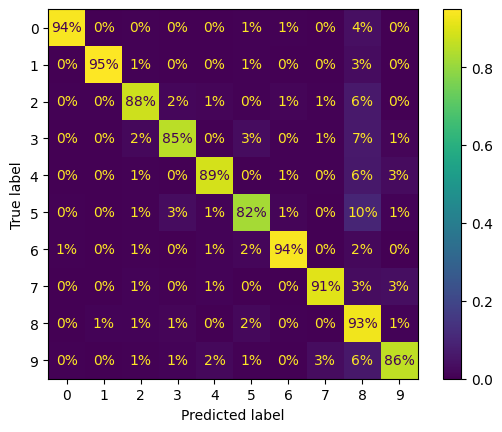

In [61]:

plt.figure(figsize = (20,20), dpi = 200)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize = "true", values_format = ".0%")
plt.show()

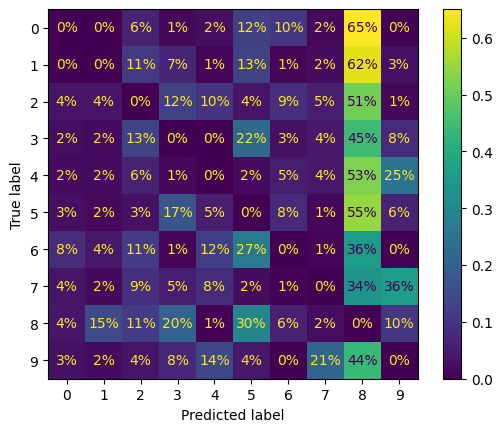

In [70]:
sample_weight = (y_train_pred!=y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight = sample_weight, normalize = "true", values_format = ".0%")


#only looks at the errors

**Multilabel Classification**

In [65]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()


y_train_large = (y_train >= "7")
y_train_odd = y_train.astype("int8") % 2 == 1

y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf.fit(X_train, y_multilabel)

# took a few seconds only

KNeighborsClassifier()

In [67]:
knn_clf.predict([first_digit_image])
# digit is 5, which is less than 7 (i.e. not large) and is odd. Hence False, True

array([[False,  True]])

In [71]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv = 3)

f1_score(y_multilabel, y_train_knn_pred, average = "macro")


#computes the average of the f1 scores, assumes equal weight for all categories/labels

#took about 3mins

0.9764102655606048

In [77]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(svm_clf, cv = 3, random_state = 42)

chain_clf.fit(X_train, y_multilabel)


#training on the first 2000, it took 3 seconds

#training it on the whole training set took 36mins

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [78]:
chain_clf.predict([first_digit_image])

# output = 0,1 i.e. False,True

array([[0., 1.]])

In [80]:
f1_score(y_multilabel, chain_clf.predict(X_train), average = "macro")
# took about 30mins

0.9875014556726243

**Multioutput Classification**

In [92]:
np.random.seed(42)
noise = np.random.randint(0,100,(len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0,100,(len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test+noise
y_test = X_test

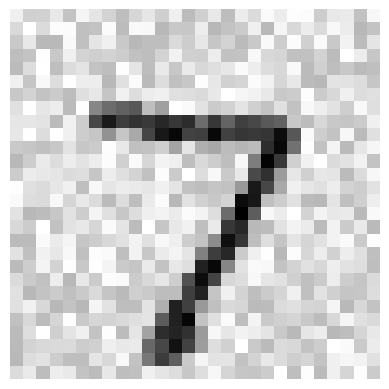

In [93]:
plot_digit(y_test_mod[0]) #noisy image of 7

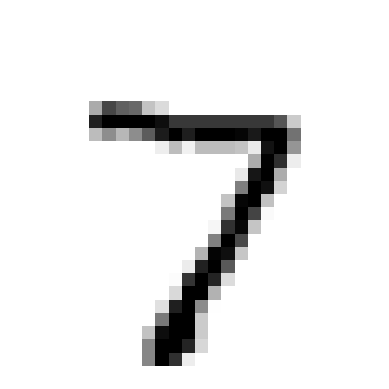

In [94]:
plot_digit(y_test[0]) #clean image of 7

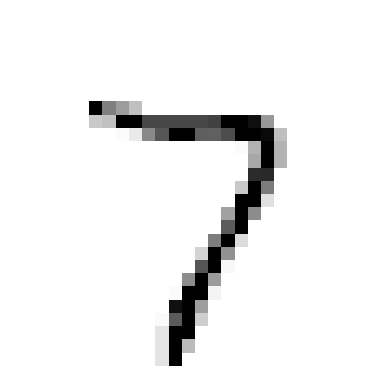

In [95]:
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit[0])

In [82]:
code_ran_noise(5, 600)

# Notes

-  Binary Classifier - distinguishes between two classes (e.g. 5 or not 5)
- Classifiers cannot be measured with normal cross-validation, the results from CV are misleading.It only answers what percentage of predictions were correct. It hides the mistakes the model makes and it treats all mistakes as equally bad (false negatives may be more serious then a false positive).

e.g. Medical Dataset
- No disease: 950
- Disease: 50

Accuracy - 95% but is useless in finding the important class.

Instead of accuracy, mertrics like:
- Recall: out of actual cancer cases how many were predicted correctly i.e. how many were caught
- Precision: Out of all predicted cancer cases, how many were actually cancer?
- F1-Score: Balance between Precision and Recall

### Confusion Matricies

Count the number of timesinstances of class A are classified as class B for all A/B pairs. Use cross_val_predict() function to get the predictions on out of sample training sets. i.e. makes a prediction on test fold.

With cross_val_predict() there is no averaging of the output like there is with the cross_val_score() function. with CVP. the predictions look like this:
```
Dataset rows:  0  1  2  3  4  5  6  7  8

Fold 1 test:   0  1  2
Fold 2 test:            3  4  5
Fold 3 test:                     6  7  8

```

The the predictions are stiched together at the end in the order of the dataset row i.e. original row.


#### How to read a Confusion Matrix:

```

array([[53892,   687],
       [ 1891,  3530]])

                   PREDICTED NEGATIVE        PREDICTIED POSITIVE
ACTUAL NEGATIVE      True Negative             False Positive
ACTUAL PRODUCTIVE    False Negative            Total Positive


Therefore:
- True Negative: 53892, The model correctly identified 53892 non-5 digits as not being 5
- False Positives: 687, The model incorrectly said 687 non-5s were 5s
- False Negatives: 1891, The model did not catch 1891 5s as 5s
- True Positives: 3530, Correctly identified 3530 5s as actually being 5s

```
### Precision and Recall

There are other metrics aside from the confusion matrix that are very usefull to use:

- Precision:

```
Precision = True Positive / (True Positive + False Positive)

"When the model predicts a 5, how often is the model actually correct"

Given that True Positive = 3530 and False Positive equal 687
Precision = 3530/(3530+687) = 83.7%


i.e. out of all the predictions of a 5, the model was correct 83.7% of the time, i.e. 83.7% of them were a 5.
```


- Recall:

```
Recall = True Positive / (True Positive + False Negative)

"Out of all the actual 5s, how many did the model successfully find"

Given that True Positive = 3530, and False Negative = 1891
Recall = 3530/(3530+1891) = 65.1%

i.e. out of all the real 5s in the dataset, the model found 65% of them

```

- F1 Score:
Combination of precision and recall to give a single metric. Useful when needing to compare to classifiers.
The F1 score is the harmonic mean of precision and recall. The harmonic mean gives more weight to low values as a result, the model will only get a high F1 score if the both recall and precision are high.

It asks "how well is the balance between both precision and recall"

```
F1 = (2*precision*recall)/(precision+recall)
```

The use of the harmonic mean instead of normal mean is to prevent one very good metric hiding the score of the other very bad metric. It favours, classifers that have a similar precisiona and recall score. This isnt always good and not always required. In some cases, e.g. detecting if a video is child friendly or not. A low recall (rejecting many safe videos) but a high precision score (keeping safe videos) may be prefered.


Unfortunately, cant have both high precision and high recall. There is a precision/recall trade off.


## Precision/Recall Trade-off
When a classifier when a makes a classification decision it computes a score for each instance using a decision function. If that score is greater than a threshold, it assigns the instance to the positive class otherwise its assigned to the negative class.

sklearb diesbt allow for setting of the decision function but does give access to the decision scores that are used to make the predicitions. Use the decision_function() method instead of the predict() method to return the score for each instance. Then any threshold can be used to make predictions based on those scores.


### How to decide the threshold

Use the "decision_function" method in cross_val_predict(sgd_classifier, X_train, y_train, cv = 3, method = "decision_function")


This will return the decision scores, then use the precision_recall_curve() function to compute precision and recall for all thresholds.


Assuming the precision is set to 90%:
can then use the argmax() functio to find the threshold for which 90% precision is achieved.



## Reciever Operating Characteristic (ROC) Curve

Tool used with binary classifiers. Similar to the precision/recall curve. It plots the recall (aka true positive rate) against false positive rate. The FPR (aka fall0out) is the ratio of negative instances that are incorrectly classified as positives.

FPR  = 1- True Negative Rate


TNR = ratio of negatie instances are correctly classified as negative. TNR is aka specificity.



### Deciding between ROC AUC and Precision/Recall (PR) Curve


General rule of thumb, the PR curve should be used over the ROC curve when the positive class is rare or when I care more about the false positives than false negatives.

If the above isnt the case, use the ROC curve (and the AUC score)


## Multiclass Classification

Binary classifiers distinguish between two classes. Some classifiers like SGDClassifier and SVC are binary classifiers only. Others like RandomForest and GaussianNB are able to handle multiple classes easily.

However, multiclass classification can still be done with binary classfication. For example, to classifiy 10 classes from 0-9, train 10 binary classifiers i.e. 10 detectors that detect each digit. e.g. 0-detector, 1-detector and so on. Each digit would be classed into one of them and the detector with the highest score would be correct answer.

For example, input image is of 5. The image is fed into a each binary classifier, the only classifier that returns a high score is the one for 5. This method is known as the one-versus-the-rest strategy (OvR) or one-versus-all(OvA) strategy.


Another strategy is called One-versus-One (OvO):
With this method, you train the binary classifier for every pair of digits. i.e. one classifier would distinguish between 0 and 1, another classifier woould distinguish between 0 and 2, another would do 1 and 2 etc

If there are N classes, then the number of classifiers to train is:
 ```
 (N*(N-1))/2
```
This means that for 10 digits, the number of binary classifiers is 45.
To classify an image, the same image has to run through 45 classifiers and see which class gives the best result.
Advantage of OvO is that each classifier needs to be trainined on the part of the training set that contains the two classes it needs to distinguish between.
e.g. if the classifier is distinguishing between 1 and 2, the training set doesnt neet to have any other digit.



Some algorithims, such as SVM classifiers, scale badly with the size of the training set and for them OvO is preferred because its faster to train many classifiers on small training sets than training a few classifiers on large training sets.

Note: Scikit-Learn will choose the optimal strategy (either OvO or OvR) based on the algorithim chosen.

e.g. with a SVM classifier, it will use the OvO strategy and train 45 classifiers.



## Error Analysis

(This part assumes that multiple models, hyperparameter tunning and all the other stages before a model is finalised have been completed. Error Analysis occurs after a model has been found and now needs to be improved)

#### Confusion Matrix

To use the confusion matrix, first make the predictions using cross_val_predict(), then pass the lables and predictions to the confusion_matrix() function.
The readability of the matrix is dependent on the number of classes, more classes = harder to read (even if coloured)


To make the errors stand out more, put zero weight on the correct predictions and then see the plot. Note: The percentages don't mean that 37% of all images of 7s were misclassified as 9s. It meas that 37% of the errors the model made on images of 7s were missclassified as 9s. (The correct predicitions were exluded). In reality, on 3% of images of 7 were misclassified as 9s. (First graph)


The confusion matrix gives insights on how to improve the classifier. From the graph (first one), it looks like there are alot of false 8s (errors on predicted 8). Errors range from 2-10%. 2% was on 6s and and 10% was on 5s

The work involved in fixing this issue, includes feature engineeirng that would help the classifier e.g. algorithim that would count the number of loops e.g. 8 has two loops, 6 has one.
Or preprocess the images using OpenCV, Pillow, Scikit-Image to make/learn some patters such as closed loops and make them stand out more

Another method is data augmentation - create slightly shifted and rotated variants of the images. Forces the model to tolerate the variations.




## Multilabel Classification

Output is multiple binary tags, e.g. for a facial recognition system that is trained to recognise A, B, and C. The output would look like [True, False, True] i.e. model recognised A, didnt recognise B, and recognised C.

To do multilabel classification, create the multiple labels i.e. bigger than 5, odd etc.
Then run the predict method (after the fitting) and get the result.
To evaluate a multilabel classifier, you can average the F1 scores of the different categories/ labels (but this evaluation method would depend on the project.)


```
f1_score(y_multilabel, y_train_knn_pred, average = "macro")
```

if the average parameter is set to "weighted" if wanting to give each label its weight based on the support providede. For example, if there are more pictures of A (relative to B and C), average should be set to weighted to reflect that.

Some classifiers dont natively support multilabel classification, e.g. SVC. In that case train one model per label. However, this method wont capture the dependencies between labels. e.g. for large numbers 7,8 and 9, there are twice as many more odd numbers in that range (7,8,9) then there are even numbers. But the classifier for the odd label doesnt know what the classifier for the large predicted. To solve this, organise the models in a chain. When a model makes a prediction, it uses the input features plus the prediction of the previous models that come before it in a chain.

Scikit-Learn has a ChainClassifier class that does this.

If the cv parameter is set. It will use the cross-validation to get clean predictions from each trained model for every instance in the training set and then these predictions will be used to train the models later down the chain.




## Multioutput Classification

Generalisation of multilabel classification, where each label can be multiclass i.e. have more than two possible values.

Example:

System taht removes noise from images. It will take a noisy digit image as input and output a clean digit image, represented as an array of pixel intensities like the MNIST images.
The classifiers output is multilabel (one label per pixel) and each label can have multiple values (pixel intensity ranges from 0-255).

Note: Line between classification and regression is blurry. This example of predicting pixel intensity is techncically closer to regression than classification. Also multioutput systems are not limited to classification tasks. Could have a system that outputs multiple labels per instance, including class labels and value labels


------------------------------------------------------------------


# Ideas